Applying default Matplotlib style...


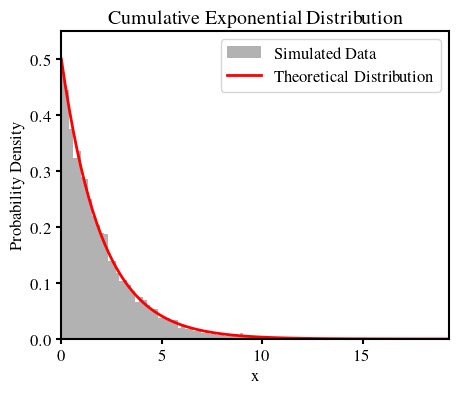

In [ ]:
import matplotlib.pyplot as plt
import maxpy
import numpy as np


def exp_distribution(x, tau):
    if x >= 0:
        return (1 / tau) * np.exp(-x / tau)
    else:
        return 0


def inverse_cumulative_exp(p, tau):
    if 0 <= p < 1:
        return -tau * np.log(1 - p)
    else:
        raise ValueError("Input must be in the range [0, 1)")


tau = 2.0
u = np.random.uniform(0, 1, 10000)

x = np.array([inverse_cumulative_exp(ui, tau) for ui in u])

plt.hist(x, bins=100, density=True, alpha=0.6, color="gray", label="Simulated Data")
plt.plot(
    np.linspace(0, max(x), 100),
    [exp_distribution(xi, tau) for xi in np.linspace(0, max(x), 100)],
    color="red",
    label="Theoretical Distribution",
)
plt.title("Cumulative Exponential Distribution")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

In [15]:
print("Mean:", np.mean(x))

Mean: 1.987843491799435


Mean: 0.006268885024836572 Variance: 0.33731371939944466


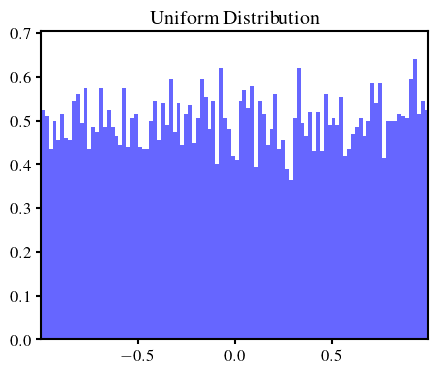

In [16]:
mu = np.random.uniform(-1, 1, 10000)

plt.hist(mu, bins=100, density=True, alpha=0.6, color="b")
plt.title("Uniform Distribution")

print("Mean:", np.mean(mu), "Variance:", np.var(mu))

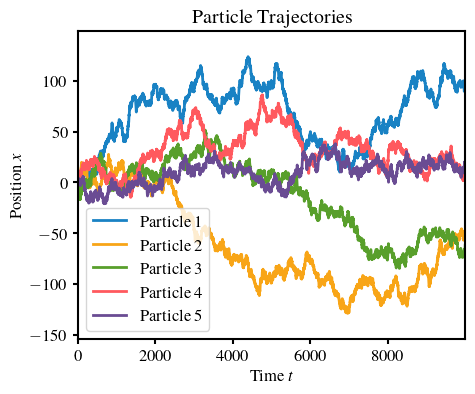

In [17]:
position = 0
velocity = 1
tau = 1
t_end = 10000.0
t_every = 100.0


def simulate_particle(position, velocity, tau, t_end):
    times = []
    positions = []
    velocities = []
    t = 0
    while t < t_end:
        times.append(t)
        positions.append(position)
        velocities.append(velocity)

        mu = np.random.uniform(-1, 1)

        # Time until next collision
        delta_t = np.random.exponential(tau)
        t += delta_t

        # Update position
        position += velocity * mu * delta_t
    return np.array(times), np.array(positions), np.array(velocities)


for _ in range(5):
    times, positions, velocities = simulate_particle(position, velocity, tau, t_end)
    plt.plot(times, positions, label=f"Particle {_ + 1}")
plt.xlabel("Time $t$")
plt.ylabel("Position $x$")
plt.title("Particle Trajectories")
plt.legend()
plt.show()


In [18]:
N_p = 1e4
t_j = np.linspace(0.1, 100, 10)

mean_pos = []
variance = []
for t_end in t_j:
    all_pos = []
    for _ in range(int(N_p)):
        times, positions, velocities = simulate_particle(position, velocity, tau, t_end)
        all_pos.append(positions[-1])

    mean_pos.append(np.mean(all_pos))
    variance.append(np.mean(np.array(all_pos) ** 2) - np.mean(all_pos) ** 2)

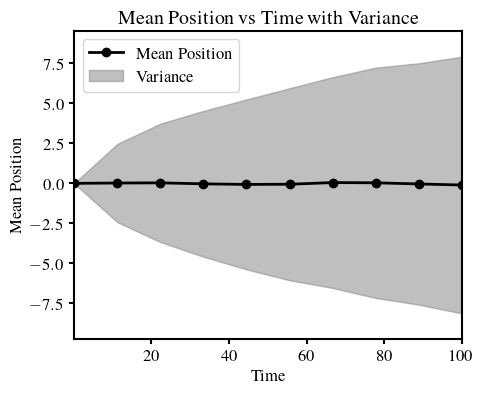

In [19]:
plt.plot(t_j, mean_pos, color="black", marker="o", label="Mean Position")
plt.fill_between(
    t_j,
    np.array(mean_pos) - np.sqrt(variance),
    np.array(mean_pos) + np.sqrt(variance),
    alpha=0.5,
    color="gray",
    label="Variance",
)
plt.xlabel("Time")
plt.ylabel("Mean Position")
plt.title("Mean Position vs Time with Variance")
plt.legend()
plt.show()

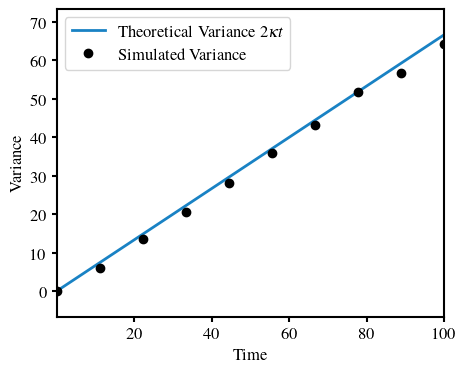

In [20]:
kappa = 1 / 3 * velocity**2 * tau

plt.plot(t_j, 2 * kappa * t_j, label="Theoretical Variance $2\\kappa t$")
plt.plot(t_j, variance, "o", color="black", label="Simulated Variance")

plt.xlabel("Time")
plt.ylabel("Variance")
plt.legend()
plt.show()

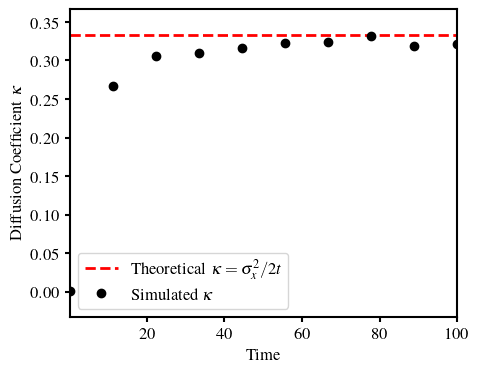

In [21]:
plt.hlines(kappa, t_j[0], t_j[-1], colors="r", linestyles="--", label="Theoretical $\\kappa=\\sigma_x^2/2t$")
plt.plot(t_j, variance / (2 * t_j), "o", color="black", label="Simulated $\\kappa$")

plt.xlabel("Time")
plt.ylabel("Diffusion Coefficient $\\kappa$")
plt.legend()
plt.show()

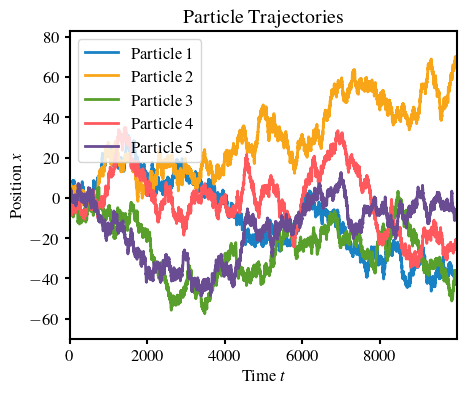

In [ ]:
position = 0
velocity = 1
tau = 1
t_end = 10000.0
t_every = 100.0


def simulate_particle(position, velocity, tau, t_end):
    times = []
    positions = []
    velocities = []
    t = 0
    while t < t_end:
        times.append(t)
        positions.append(position)
        velocities.append(velocity)

        mu = np.random.uniform(-1, 1)

        # Time until next collision
        delta_t = tau  # np.random.exponential(tau)
        t += delta_t

        # Update position
        position += velocity * mu * delta_t
    return np.array(times), np.array(positions), np.array(velocities)


for _ in range(5):
    times, positions, velocities = simulate_particle(position, velocity, tau, t_end)
    plt.plot(times, positions, label=f"Particle {_ + 1}")
plt.xlabel("Time $t$")
plt.ylabel("Position $x$")
plt.title("Particle Trajectories")
plt.legend()
plt.show()


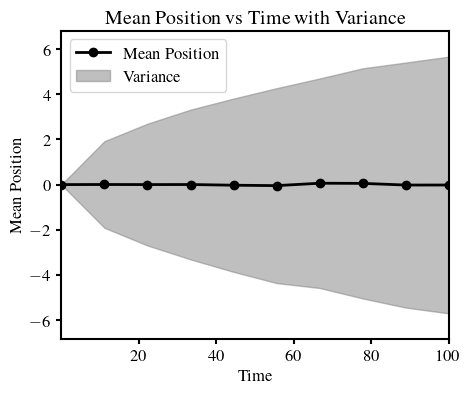

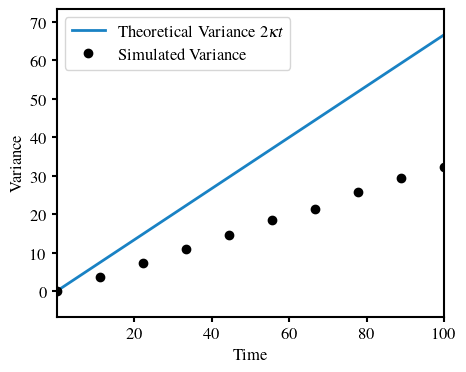

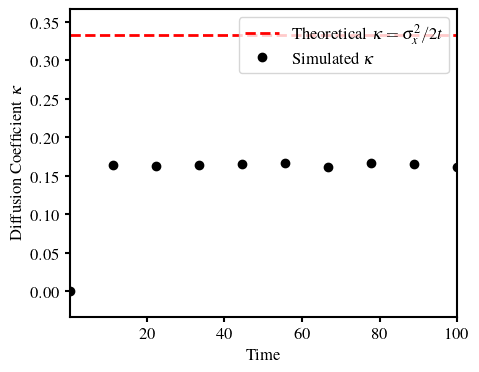

In [23]:
N_p = 1e4
t_j = np.linspace(0.1, 100, 10)

mean_pos = []
variance = []
for t_end in t_j:
    all_pos = []
    for _ in range(int(N_p)):
        times, positions, velocities = simulate_particle(position, velocity, tau, t_end)
        all_pos.append(positions[-1])

    mean_pos.append(np.mean(all_pos))
    variance.append(np.mean(np.array(all_pos) ** 2) - np.mean(all_pos) ** 2)

plt.plot(t_j, mean_pos, color="black", marker="o", label="Mean Position")
plt.fill_between(
    t_j,
    np.array(mean_pos) - np.sqrt(variance),
    np.array(mean_pos) + np.sqrt(variance),
    alpha=0.5,
    color="gray",
    label="Variance",
)
plt.xlabel("Time")
plt.ylabel("Mean Position")
plt.title("Mean Position vs Time with Variance")
plt.legend()
plt.show()

kappa = 1 / 3 * velocity**2 * tau

plt.plot(t_j, 2 * kappa * t_j, label="Theoretical Variance $2\\kappa t$")
plt.plot(t_j, variance, "o", color="black", label="Simulated Variance")

plt.xlabel("Time")
plt.ylabel("Variance")
plt.legend()
plt.show()

plt.hlines(kappa, t_j[0], t_j[-1], colors="r", linestyles="--", label="Theoretical $\\kappa=\\sigma_x^2/2t$")
plt.plot(t_j, variance / (2 * t_j), "o", color="black", label="Simulated $\\kappa$")

plt.xlabel("Time")
plt.ylabel("Diffusion Coefficient $\\kappa$")
plt.legend()
plt.show()

In [ ]:
momenta = [0.3, 1, 3, 10]

alpha = 1 / 3
tau_0 = 1.0


def tau(p):
    return tau_0 * p**alpha


N_p = 1e3
t_j = np.linspace(0.1, 100, 10)
kappa_mc_p = []
for p in momenta:
    mean_pos = []
    variance = []
    for t_end in t_j:
        all_pos = []
        for _ in range(int(N_p)):
            times, positions, velocities = simulate_particle(position, velocity, tau(p), t_end)
            all_pos.append(positions[-1])

        mean_pos.append(np.mean(all_pos))
        variance.append(np.mean(np.array(all_pos) ** 2) - np.mean(all_pos) ** 2)

    kappa_mc = variance[-1] / (2 * t_j[-1])
    kappa_mc_p.append(kappa_mc)


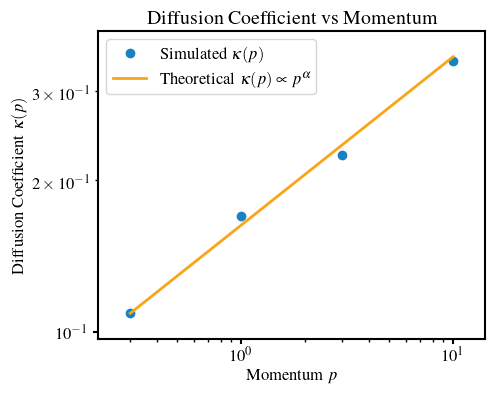

In [ ]:
p0 = 0.18

# fit in log-log space to find p0 and alpha
log_momenta = np.log(momenta)
log_kappa_mc_p = np.log(kappa_mc_p)
coefficients = np.polyfit(log_momenta, log_kappa_mc_p, 1)
alpha_fit = coefficients[0]
p0_fit = np.exp(coefficients[1])

# add margin
plt.margins(0.1)

plt.plot(momenta, kappa_mc_p, "o", label="Simulated $\\kappa(p)$")
plt.plot(momenta, p0_fit * np.array(momenta) ** alpha, label="Theoretical $\\kappa(p) \\propto p^\\alpha$")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Momentum $p$")
plt.ylabel("Diffusion Coefficient $\\kappa(p)$")
plt.title("Diffusion Coefficient vs Momentum")
plt.legend()
plt.show()